# Experiment 2 — Transformation Recovery (unknown correspondences)

**Goal:** Given point clouds $P = T_1(S)$ and $Q = T_2(S)$ **without known correspondences**,
recover the ground-truth transformation $T_{\mathrm{gt}} = T_2 \circ T_1^{-1}$ using ICP
(EM with nearest-neighbor E-step and SVD Procrustes M-step).

See `Notes/Transformation Recovery.md` and `Experiments/Transformation Recovery 2.md`.

In [1]:
import sys
sys.path.insert(0, '.')

import numpy as np
import matplotlib.pyplot as plt

from point_cloud import PointCloud
from transformation import RigidTransformation
from icp import ICP
plt.style.use("seaborn-v0_8-whitegrid")

## 1. Synthetic data generation

Same setup as Experiment 1:
- $S$: random irregular point cloud
- $T_1, T_2$: random rigid transformations with small per-point Gaussian noise
- $P = T_1(S)$, $Q = T_2(S)$ — **matching is unknown** this time

In [2]:
SEED = 42
N = 2000
NOISE_STD = .01
T_SCALE = 8.0

np.random.seed(SEED)

S = PointCloud(np.random.uniform(low=-30, high=30, size=(N, 3)))

T1 = RigidTransformation.random(noise_std=NOISE_STD, t_scale=T_SCALE)
T2 = RigidTransformation.random(noise_std=NOISE_STD, t_scale=T_SCALE)

P = T1.apply(S)
Q = T2.apply(S)

print(f"S:  {S}")
print(f"T1: {T1}")
print(f"T2: {T2}")
print(f"P:  {P}")
print(f"Q:  {Q}")

S:  PointCloud(n=2000)
T1: RigidTransformation(rot=149.5°, t_norm=5.17)
T2: RigidTransformation(rot=153.1°, t_norm=5.87)
P:  PointCloud(n=2000)
Q:  PointCloud(n=2000)


## 2. Ground truth

Because $p_i = T_1(s_i)$ and $q_i = T_2(s_i)$, the ideal map is
$$T_{\mathrm{gt}} = T_2 \circ T_1^{-1}$$

In [3]:
T_gt = T2.compose(T1.inverse())
R_gt, t_gt = T_gt.R, T_gt.t

print("Ground-truth rotation matrix R_gt:")
print(np.round(R_gt, 4))
print(f"\nGround-truth translation t_gt: {np.round(t_gt, 4)}")
print(f"Rotation angle: {np.degrees(np.arccos(np.clip((np.trace(R_gt)-1)/2, -1, 1))):.2f}°")

Ground-truth rotation matrix R_gt:
[[ 0.9705 -0.1231  0.2075]
 [ 0.1524  0.9795 -0.132 ]
 [-0.187   0.1597  0.9693]]

Ground-truth translation t_gt: [-7.7912 -4.4575 -0.117 ]
Rotation angle: 16.34°


## 3. Run ICP

EM loop:
- **E-step:** nearest-neighbor matching (KD-tree)
- **M-step:** SVD Procrustes fit on matched pairs
- **Convergence:** $\|R_{\mathrm{step}} - I\|_F + \|t_{\mathrm{step}}\| < \varepsilon$

In [4]:
icp = ICP(max_iter=100, tol=1e-6, verbose=True)
result = icp.fit(P, Q)

print(f"\nConverged: {result.converged}")
print(f"Iterations: {result.n_iterations}")
print(f"Recovered: {result.transformation}")

Iter   1 | mean residual: 3.3438
Iter   2 | mean residual: 3.2370
Iter   3 | mean residual: 3.1577
Iter   4 | mean residual: 3.0988
Iter   5 | mean residual: 3.0535
Iter   6 | mean residual: 3.0148
Iter   7 | mean residual: 2.9845
Iter   8 | mean residual: 2.9517
Iter   9 | mean residual: 2.9173
Iter  10 | mean residual: 2.8852
Iter  11 | mean residual: 2.8466
Iter  12 | mean residual: 2.7974
Iter  13 | mean residual: 2.7284
Iter  14 | mean residual: 2.6058
Iter  15 | mean residual: 2.4119
Iter  16 | mean residual: 2.1870
Iter  17 | mean residual: 1.8410
Iter  18 | mean residual: 1.1325
Iter  19 | mean residual: 0.1074
Iter  20 | mean residual: 0.0227
Iter  21 | mean residual: 0.0227
Converged at iteration 21 (delta=8.80e-15)

Converged: True
Iterations: 21
Recovered: RigidTransformation(rot=16.3°, t_norm=8.98)


## 4. Evaluation

In [5]:
def rotation_angle_error(R1: np.ndarray, R2: np.ndarray) -> float:
    """Angular distance between two SO(3) matrices in degrees."""
    cos = np.clip((np.trace(R1.T @ R2) - 1) / 2, -1.0, 1.0)
    return float(np.degrees(np.arccos(cos)))

T_icp = result.transformation
Q_pred = T_icp.apply(P)
residuals = np.linalg.norm(Q_pred.points - Q.points, axis=1)

rot_err = rotation_angle_error(R_gt, T_icp.R)
t_err   = np.linalg.norm(t_gt - T_icp.t)

print("=== ICP result ===")
print(f"Rotation error    : {rot_err:.4f}°")
print(f"Translation error : {t_err:.4f}")
print(f"Mean point residual: {residuals.mean():.4f}")
print(f"Max  point residual: {residuals.max():.4f}")

=== ICP result ===
Rotation error    : 0.0008°
Translation error : 0.0011
Mean point residual: 0.0227
Max  point residual: 0.0637


## 5. Convergence plot & residual histogram

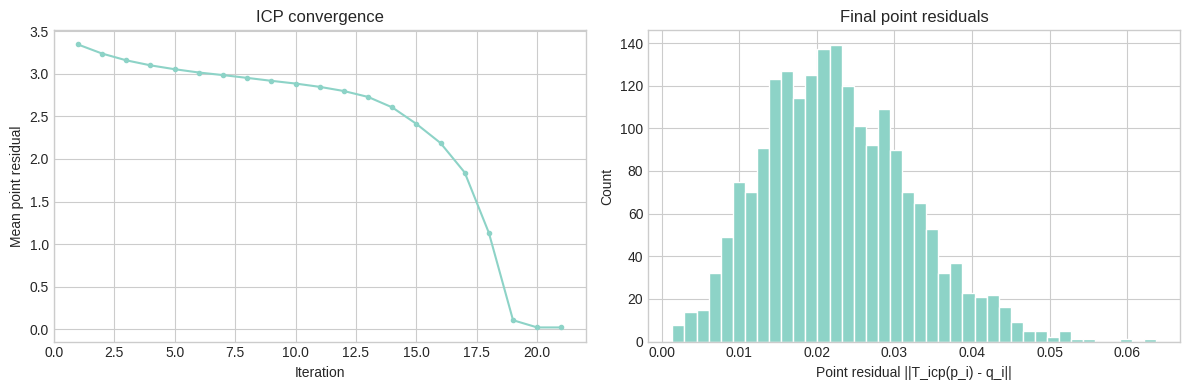

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Convergence curve
ax = axes[0]
ax.plot(range(1, len(result.mean_residuals) + 1), result.mean_residuals, marker='o', ms=3)
ax.set_xlabel('Iteration')
ax.set_ylabel('Mean point residual')
ax.set_title('ICP convergence')

# Residual histogram
ax = axes[1]
ax.hist(residuals, bins=40)
ax.set_xlabel('Point residual ||T_icp(p_i) - q_i||')
ax.set_ylabel('Count')
ax.set_title('Final point residuals')

plt.tight_layout()
plt.savefig('experiment_2_results.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Alignment snapshots

Source cloud (blue) vs. target cloud (red) at selected iterations, projected onto XY.
Shows how the cloud physically moves into alignment over the EM iterations.

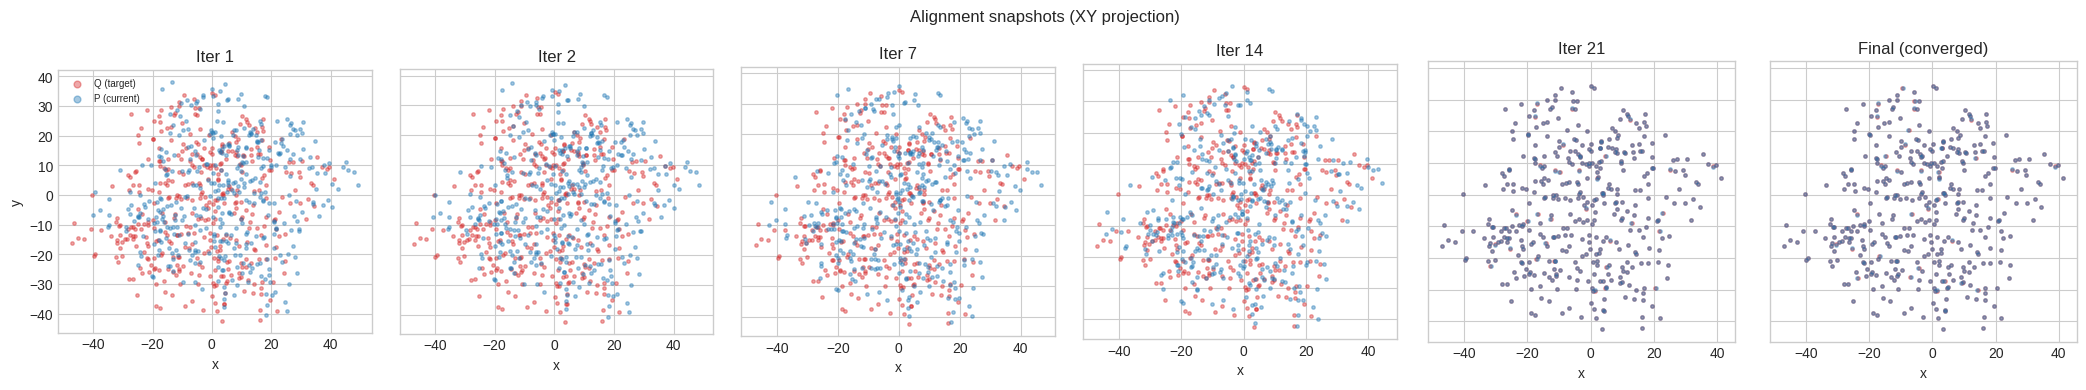

In [7]:
n_iters = result.n_iterations
# Pick ~4 evenly spaced iterations + final
snap_iters = sorted(set(
    [0, 1] + list(np.linspace(0, n_iters - 1, 4, dtype=int)) + [n_iters - 1]
))
n_snaps = len(snap_iters)

fig, axes = plt.subplots(1, n_snaps + 1, figsize=(3.5 * (n_snaps + 1), 3.5), sharey=True)

# Subsample for readability
idx = np.random.choice(len(Q), size=400, replace=False)

for ax, it in zip(axes, snap_iters):
    cloud = result.cloud_history[it]
    ax.scatter(Q.points[idx, 0], Q.points[idx, 1], s=6, alpha=0.4, color='tab:red', label='Q (target)')
    ax.scatter(cloud.points[idx, 0], cloud.points[idx, 1], s=6, alpha=0.4, color='tab:blue', label='P (current)')
    ax.set_title(f'Iter {it + 1}')
    ax.set_xlabel('x')
    ax.set_aspect('equal')

axes[0].set_ylabel('y')
axes[0].legend(markerscale=2, loc='upper left', fontsize=7)

# Final panel: converged result
final_cloud = result.transformation.apply(P)
axes[-1].scatter(Q.points[idx, 0], Q.points[idx, 1], s=6, alpha=0.4, color='tab:red')
axes[-1].scatter(final_cloud.points[idx, 0], final_cloud.points[idx, 1], s=6, alpha=0.4, color='tab:blue')
axes[-1].set_title('Final (converged)')
axes[-1].set_xlabel('x')
axes[-1].set_aspect('equal')

plt.suptitle('Alignment snapshots (XY projection)', y=1.02)
plt.tight_layout()
plt.savefig('experiment_2_snapshots.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Assignment churn

Fraction of points that change their nearest-neighbor assignment between consecutive iterations.
When this drops to ~0 the E-step has stabilised — the real convergence signal.

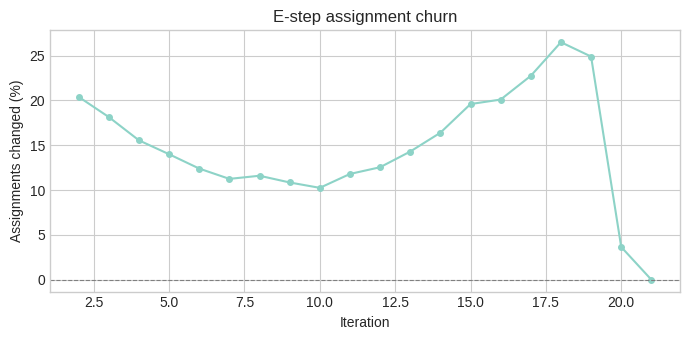

In [8]:
assignments = result.assignment_history
churn = [
    np.mean(assignments[i] != assignments[i - 1]) * 100
    for i in range(1, len(assignments))
]

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(range(2, len(assignments) + 1), churn, marker='o', ms=4)
ax.set_xlabel('Iteration')
ax.set_ylabel('Assignments changed (%)')
ax.set_title('E-step assignment churn')
ax.axhline(0, color='gray', lw=0.8, linestyle='--')
plt.tight_layout()
plt.savefig('experiment_2_churn.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Transformation trajectory toward ground truth

Rotation error (°) and translation error vs. $T_\mathrm{gt}$ at each iteration.
Shows how quickly the recovered transformation converges to the ground truth.

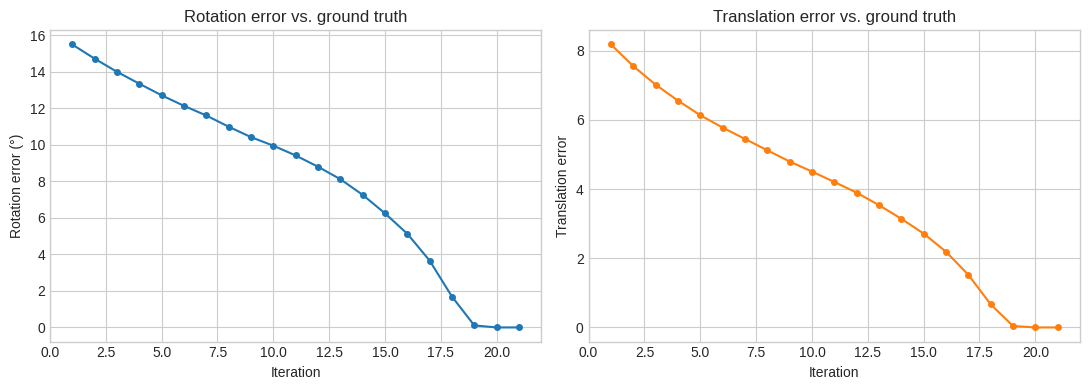

Initial rotation error : 15.50°  →  Final: 0.0008°
Initial translation err: 8.18    →  Final: 0.0011


In [9]:
rot_errors = [rotation_angle_error(R_gt, T.R) for T in result.transform_history]
t_errors   = [np.linalg.norm(t_gt - T.t)       for T in result.transform_history]
iters = range(1, len(rot_errors) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.plot(iters, rot_errors, marker='o', ms=4, color='tab:blue')
ax1.set_xlabel('Iteration')
ax1.set_ylabel('Rotation error (°)')
ax1.set_title('Rotation error vs. ground truth')

ax2.plot(iters, t_errors, marker='o', ms=4, color='tab:orange')
ax2.set_xlabel('Iteration')
ax2.set_ylabel('Translation error')
ax2.set_title('Translation error vs. ground truth')

plt.tight_layout()
plt.savefig('experiment_2_trajectory.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Initial rotation error : {rot_errors[0]:.2f}°  →  Final: {rot_errors[-1]:.4f}°")
print(f"Initial translation err: {t_errors[0]:.2f}    →  Final: {t_errors[-1]:.4f}")